In [1]:
import pandas as pd
#Cargamos el data set de datos

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print("CSV leido exitosamente")


CSV leido exitosamente


In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print(df.info())
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
median_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)


print("todo correcto")
print(df.info())


todo correcto
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [8]:
#Entrenamos el modelo. X los valores que le damos para que estudie e Y lo que tiene que adivinar
#Eliminamos la proximidad al mar, de moemtno, porque no entiende string
#Eliminamos el valor medio de las casas, pues es lo que queremos adivinar
X = df.drop(["ocean_proximity","median_house_value"],axis=1)
#axis = 1 indica la eliminacion de la columna. axis =0 indica la fila
Y = df["median_house_value"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Datos totales: {len(df)}")
print(f"Entrenamiento: {len(X_train)} casas")
print(f"Pruebas (Examen): {len(X_test)} casas")

Datos totales: 20640
Entrenamiento: 16512 casas
Pruebas (Examen): 4128 casas


In [10]:
#Entrenamos el modelo de regresion lineal 
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,Y_train)

print("Modelo Entrenado, listo para predecir")

Modelo Entrenado, listo para predecir


In [14]:
prediction = model.predict(X_test)

compare = pd.DataFrame ({
    'Precio Real': Y_test.values[:10],
    'Predicción IA': prediction[:10],
    'Diferencia': Y_test.values[:10] - prediction[:10]
})

print("--- Comparación de Precios ---")
print(compare)

--- Comparación de Precios ---
   Precio Real  Predicción IA     Diferencia
0      47700.0   63736.591338  -16036.591338
1      45800.0  154344.594319 -108544.594319
2     500001.0  253073.194287  246927.805713
3     218600.0  263507.746536  -44907.746536
4     278000.0  266883.359611   11116.640389
5     158700.0  155403.494466    3296.505534
6     198200.0  287058.654200  -88858.654200
7     157500.0  223660.781552  -66160.781552
8     340000.0  257045.027183   82954.972817
9     446600.0  404273.366113   42326.633887


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(Y_test, prediction)
r2 = r2_score(Y_test, prediction)

print(f"\nError Medio (MAE): ${mae:.2f}")
print(f"Puntuación R2 (0 a 1): {r2:.2f}")


Error Medio (MAE): $51810.48
Puntuación R2 (0 a 1): 0.61


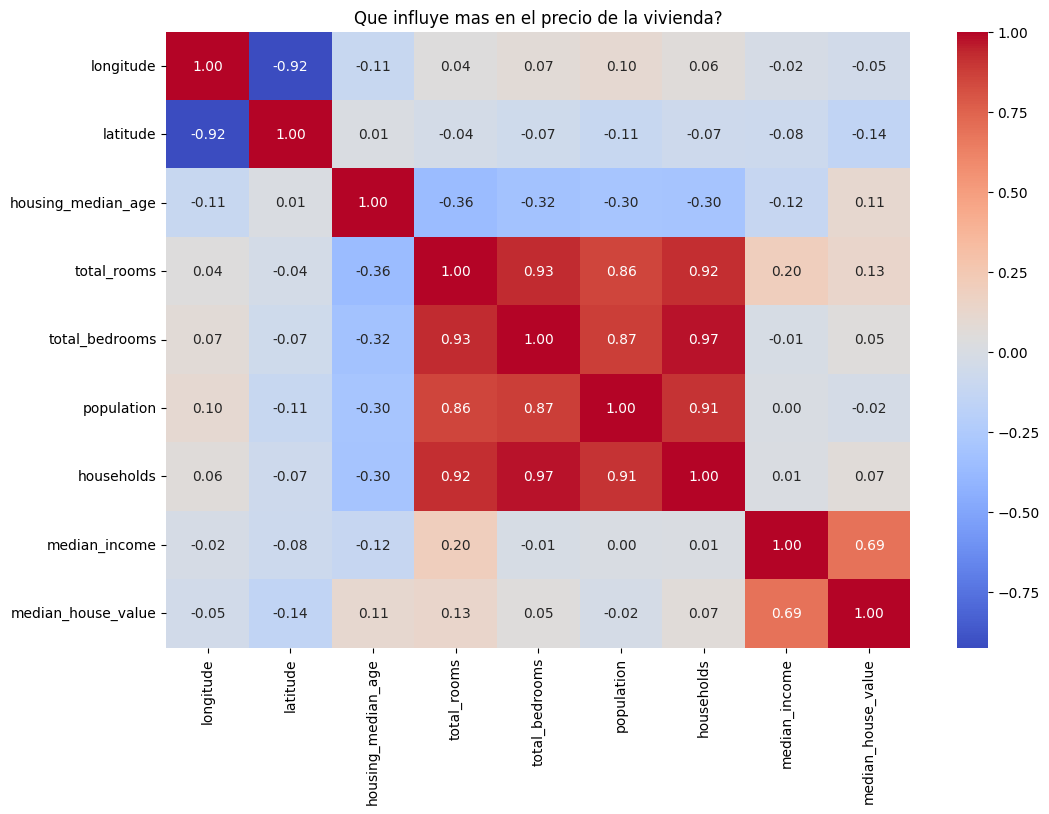

In [17]:
#Calculamos la correlacion (solo de las columnas numericas)

corr_matrix = df.select_dtypes(include=["float64"]).corr()
#Dibujamos el mapa de calor

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Que influye mas en el precio de la vivienda?")
plt.show()
